In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_people_analytics = pd.read_csv('../data/projeto_07_people_analytics.csv')

In [19]:
df_people_analytics.head()

,funcionario_id,departamento,cargo,idade,sexo,tempo_empresa_meses,salario_mensal,satisfacao_trabalho,satisfacao_ambiente,equilibrio_vida_trabalho,promovido_ultimos_2anos,horas_extras_mes,num_projetos,avaliacao_desempenho,saiu_da_empresa,data_admissao,data_saida
0,FUN-00001,RH,Coordenador,43,M,50,14397.29,3.0,4,5,1,14,6,2.1,1,2020-10-23,2024-12-01
1,FUN-00002,Suporte,Júnior,35,F,1,2623.53,4.0,5,3,0,5,6,2.7,0,2024-11-01,NaN
2,FUN-00003,Operações,Júnior,29,F,22,3441.92,4.0,3,1,0,2,4,3.9,1,2023-02-10,2024-12-01
3,FUN-00004,Produto,Sênior,29,M,32,13489.71,2.0,2,4,1,4,2,3.5,0,2022-04-16,NaN
4,FUN-00005,Suporte,Pleno,37,M,46,8023.80,2.0,4,3,0,0,1,3.4,1,2021-02-20,2024-12-01


### Existe gap salarial de gênero? Compare salários de homens e mulheres no mesmo cargo e departamento. Quantifique a diferença.

In [20]:
## Posso começar vendo a média salarial de homens por cargo e departamento, adicionando na mesma tabela a média das mulheres e fazendo a diferença dos dois. Depois estudar a diferença das médias, talvez um gráfico de dispersão me ajude e enxergar

## Os dados estão prontos pra serem usados?
## Departamento, Cargo, Sexo, Salario

# Não existem valores nulos
print(df_people_analytics[["cargo", "departamento", "sexo", "salario_mensal"]].notnull().sum(), "\n")

## Essas são as categorias dos dados
print("Departamentos:", list(df_people_analytics['departamento'].unique()))
print("Cargos:", list(df_people_analytics['cargo'].unique()))

##
print("Duplicatas de funcionario:", df_people_analytics["funcionario_id"].duplicated().sum())
print("\n",df_people_analytics.dtypes)
df_people_analytics.describe()

cargo             1200
departamento      1200
sexo              1200
salario_mensal    1200
dtype: int64 

Departamentos: ['RH', 'Suporte', 'Operações', 'Produto', 'Financeiro', 'Vendas', 'Engenharia', 'Marketing']
Cargos: ['Coordenador', 'Júnior', 'Sênior', 'Pleno', 'Gerente']
Duplicatas de funcionario: 0

 funcionario_id                  str
departamento                    str
cargo                           str
idade                         int64
sexo                            str
tempo_empresa_meses           int64
salario_mensal              float64
satisfacao_trabalho         float64
satisfacao_ambiente           int64
equilibrio_vida_trabalho      int64
promovido_ultimos_2anos       int64
horas_extras_mes              int64
num_projetos                  int64
avaliacao_desempenho        float64
saiu_da_empresa               int64
data_admissao                   str
data_saida                      str
dtype: object


,idade,tempo_empresa_meses,salario_mensal,satisfacao_trabalho,satisfacao_ambiente,equilibrio_vida_trabalho,promovido_ultimos_2anos,horas_extras_mes,num_projetos,avaliacao_desempenho,saiu_da_empresa
count,1200.000000,1200.000000,1200.000000,1155.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1171.000000,1200.000000
mean,32.585000,36.029167,8152.508517,2.740260,2.586667,2.550000,0.252500,8.231667,4.129167,3.484543,0.248333
std,6.546003,22.925669,4469.911392,1.116319,1.124815,1.117381,0.434628,5.637181,1.969530,0.797459,0.432226
min,22.000000,1.000000,2101.610000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,28.000000,18.000000,4400.552500,2.000000,2.000000,2.000000,0.000000,4.000000,2.000000,2.900000,0.000000
50%,32.000000,35.000000,7087.290000,3.000000,3.000000,3.000000,0.000000,8.000000,4.000000,3.500000,0.000000
75%,37.000000,52.250000,10703.650000,4.000000,3.000000,3.000000,1.000000,12.000000,6.000000,4.100000,0.000000
max,55.000000,117.000000,27290.830000,5.000000,5.000000,5.000000,1.000000,28.000000,7.000000,5.000000,1.000000


Média Simples por sexo:
   sexo     mean  count   median
0    F  7483.16    596  6519.96
1    M  8812.99    604  7568.83


array([<Axes: title={'center': 'F'}, ylabel='Frequency'>,
       <Axes: title={'center': 'M'}, ylabel='Frequency'>], dtype=object)

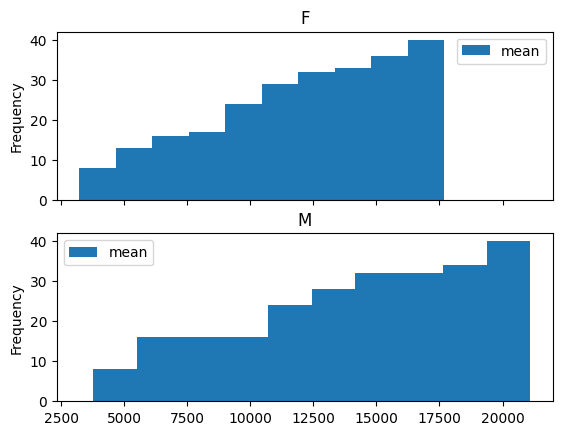

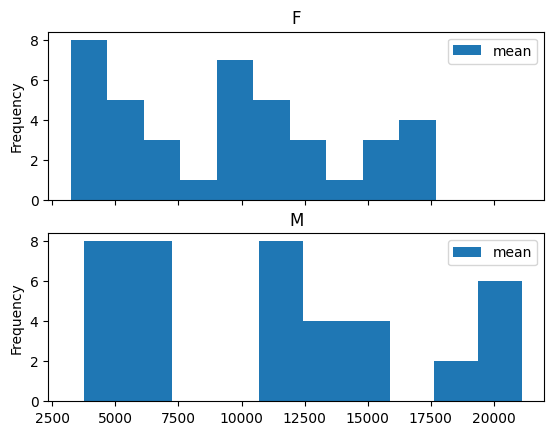

In [21]:
## Noção geral do salário e da distribuição dos salários na empresa
print("Média Simples por sexo:\n", df_people_analytics.groupby(["sexo"])["salario_mensal"].agg(['mean','count','median']).reset_index().round(2))

df_media_salarial = df_people_analytics.groupby(["cargo", "departamento", "sexo"], as_index=False)["salario_mensal"].agg(['mean', 'count']).round(2)

df_media_salarial.plot.hist(column=["mean"], by="sexo", sharex=True, sharey=True, bins=10, cumulative=True)
df_media_salarial.plot.hist(column=["mean"], by="sexo", sharex=True, sharey=True, bins=10, cumulative=False)


In [22]:
## Em quantos departamentos os homens ganham mais que mulheres? É difuso ou é concentrado em poucos departamentos? Pode ser um sintoma de uma área se manifestando como um desvio no resultado geral
## Qual a diferença média do salário do homem e da mulher por departamento?


df_delta_media_salarial = df_media_salarial.set_index(["cargo", "departamento","sexo"]).unstack("sexo").reset_index()

# Cálculo da Diferença de Média Salarial por cargo e departamento entre homens e mulheres
df_delta_media_salarial["delta_media_salarial"] = df_delta_media_salarial["mean", "M"] - df_delta_media_salarial["mean", "F"]

print("Resumo estatístico da diferença de média salarial entre homens e mulheres\n",
      df_delta_media_salarial.describe().round(2),
     "\n---\n"
     )

## Departamentos com menor e maior diferença de média salarial
print("Departamento com a menor diferença:\n",
      df_delta_media_salarial[df_delta_media_salarial["delta_media_salarial"] == df_delta_media_salarial["delta_media_salarial"].min()],
      "\n---\n")

print("Departamento com a maior diferença:\n",
    df_delta_media_salarial[df_delta_media_salarial["delta_media_salarial"] == df_delta_media_salarial["delta_media_salarial"].max()])

Resumo estatístico da diferença de média salarial entre homens e mulheres
            mean            count        delta_media_salarial
sexo          F         M      F      M                     
count     40.00     40.00  40.00  40.00                40.00
mean    9413.98  11179.23  14.90  15.10              1765.25
std     4622.46   5645.40   8.03   7.65              1347.57
min     3227.41   3767.25   3.00   3.00               362.92
25%     5815.11   6930.07   8.75   6.75               754.50
50%     9362.76  11001.02  13.50  16.00              1364.08
75%    12498.87  14408.19  22.00  21.00              2352.92
max    17699.10  21103.56  30.00  29.00              5542.99 
---

Departamento com a menor diferença:
        cargo departamento     mean          count     delta_media_salarial
sexo                             F        M     F   M                     
16    Júnior   Engenharia  3562.13  3925.05    21  16               362.92 
---

Departamento com a maior diferença:
     

array([<Axes: title={'center': 'Coordenador'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Gerente'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Júnior'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Pleno'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Sênior'}, ylabel='Frequency'>],
      dtype=object)

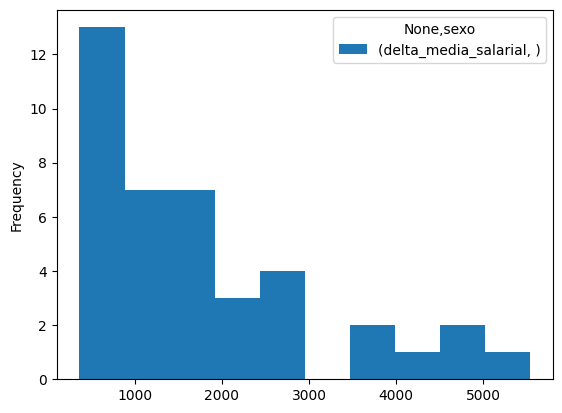

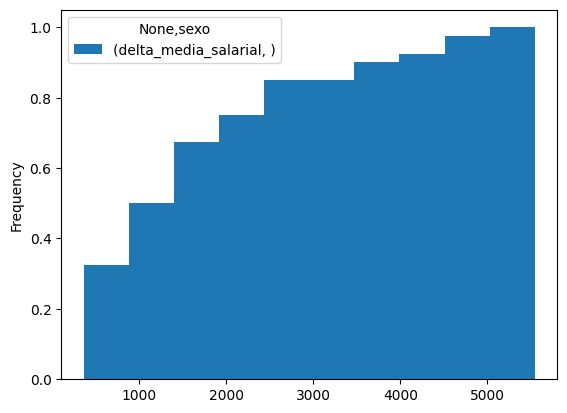

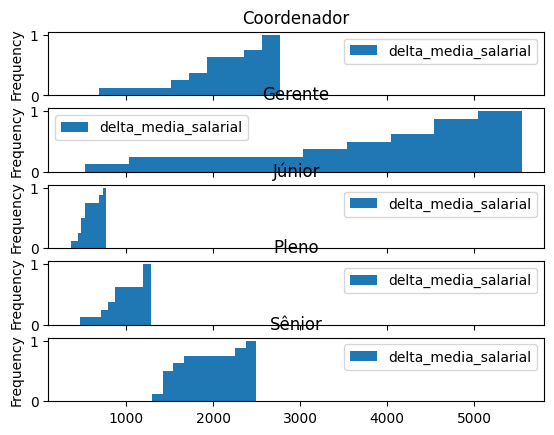

In [23]:
## Exibição gráfica como todos setores e cargos possuem homens ganhando mais
df_delta_media_salarial.plot.hist(column="delta_media_salarial")

df_delta_media_salarial.plot.hist(column="delta_media_salarial", cumulative=True, density=True)

## Preparar pro gráfico por cargo

df_delta_media_salarial.columns = ['_'.join(map(str, col)).strip() for col in df_delta_media_salarial.columns.values]

df_delta_media_salarial.columns = df_delta_media_salarial.columns.str.strip("_")

df_delta_media_salarial.plot.hist(column="delta_media_salarial", cumulative=True, density=True, by="cargo", sharex=True)

#print(df_delta_media_salarial.droplevel(1).columns)

# df_delta_media_salarial.reset_index().plot.hist(column="delta_media_salarial", cumulative=True, density=True, by="cargo")